# Model Evaluation & Comparison - Stanford Dogs

Purpose: load all trained models and provide a comprehensive comparison.

**Models compared:**
1. ResNet50 (Frozen)
2. ResNet50 (Fine-Tuned)
3. EfficientNetB0 (Frozen)
4. EfficientNetB0 (Fine-Tuned)
5. Feature Fusion (Frozen backbones)

**Analyses:**
- Overall accuracy, loss, top-5 accuracy
- Training history comparison
- Per-model confusion analysis
- Best model selection

The contents of this notebook:

- [Models Comparison](#models-comparison)
  - [1. Imports & Setup](#1-imports--setup)
  - [2. Load Raw Dataset](#2-load-raw-dataset)
  - [3. Load ALL Training Histories](#3-load-all-training-histories)
  - [4. Compare Training Histories](#4-compare-training-histories)
  - [5. Load Best Model and Evaluate](#5-load-best-model-and-evaluate)
  - [6. Detailed Analysis of Best Model](#6-detailed-analysis-of-best-model)
  - [7. Save Best Model Info](#7-save-best-model-info)
  - [8. Summary](#summary)

## Models Comparison

### 1. Imports & Setup

In [1]:
import sys
sys.path.insert(0, "..")

import os
import json
import yaml
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
cfg = yaml.safe_load(open("../config/default.yaml"))

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


### 2. Load Raw Dataset

In [2]:
from src.data.dataset import load_stanford_dogs, get_num_classes

(train_ds, test_ds), ds_info, class_names = load_stanford_dogs(as_supervised=True)
num_classes = get_num_classes(ds_info)

print(f"Dataset: {ds_info.name}")
print(f"Number of classes: {num_classes}")

Dataset: stanford_dogs
Number of classes: 120


### 3. Load ALL Training Histories

In [3]:
histories_dir = cfg["paths"]["histories"]

history_files = {
    "ResNet50 Frozen": "resnet50_frozen.json",
    "ResNet50 Fine-Tuned": "resnet50_finetuned.json",
    "EfficientNetB0 Frozen": "efficientnetb0_frozen.json",
    "EfficientNetB0 Fine-Tuned": "efficientnetb0_finetuned.json",
    "Fusion (Frozen Backbones)": "fusion_frozen.json",
}

histories = {}
for name, filename in history_files.items():
    filepath = os.path.join(histories_dir, filename)
    if os.path.exists(filepath):
        with open(filepath) as f:
            histories[name] = json.load(f)
        print(f"Loaded {name}")
    else:
        print(f"Missing {name} ({filename})")

print(f"\nTotal histories loaded: {len(histories)}")

Loaded ResNet50 Frozen
Loaded ResNet50 Fine-Tuned
Loaded EfficientNetB0 Frozen
Loaded EfficientNetB0 Fine-Tuned
Loaded Fusion (Frozen Backbones)

Total histories loaded: 5


### 4. Compare Training Histories

Saved plot to ../artefacts/evaluations\all_models_val_accuracy.png


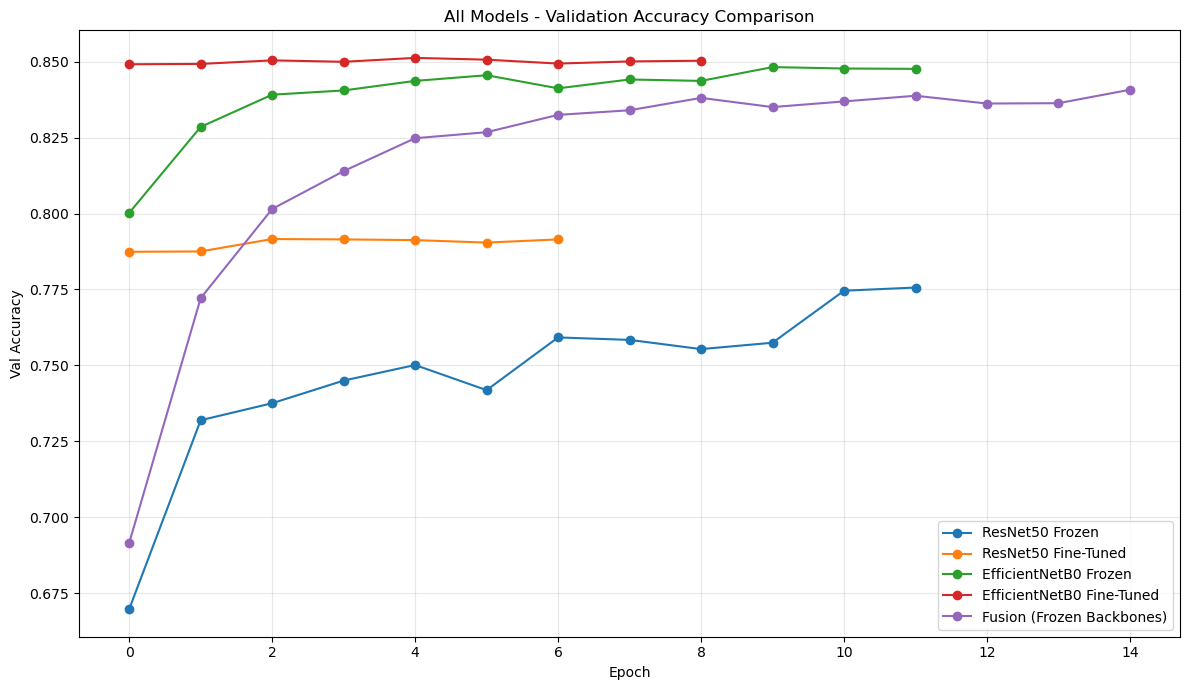

In [4]:
# validation accuracy comparison
from src.evaluation.viz import plot_multiple_histories

os.makedirs(cfg["paths"]["evaluations"], exist_ok=True)

plot_multiple_histories(
    histories,
    metric="val_accuracy",
    title="All Models - Validation Accuracy Comparison",
    figsize=(12, 7),
    save_path=os.path.join(cfg["paths"]["evaluations"], "all_models_val_accuracy.png"),
)

Saved plot to ../artefacts/evaluations\all_models_val_loss.png


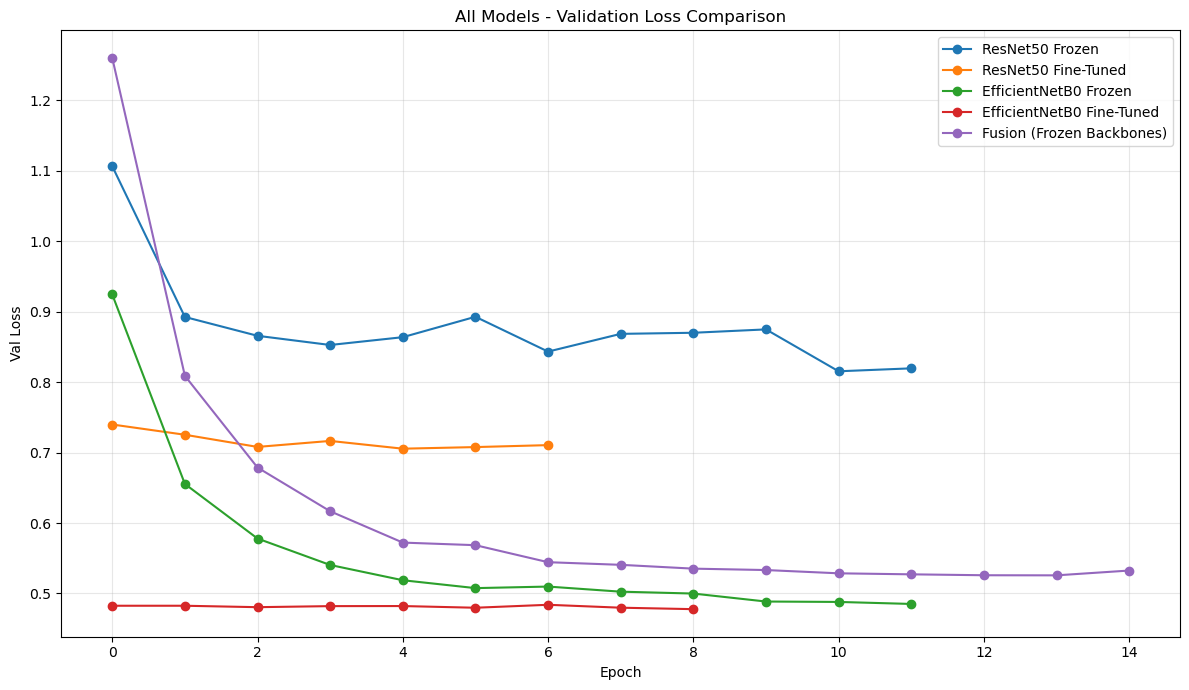

In [5]:
# validation loss comparison
plot_multiple_histories(
    histories,
    metric="val_loss",
    title="All Models - Validation Loss Comparison",
    figsize=(12, 7),
    save_path=os.path.join(cfg["paths"]["evaluations"], "all_models_val_loss.png"),
)

In [6]:
# Extract best epoch metrics from each history
final_metrics = {}

for model_name, history in histories.items():
    history = history.history if hasattr(history, "history") else history
    best_epoch = int(np.argmax(history["val_accuracy"]))
    best_val_acc = float(history["val_accuracy"][best_epoch])
    best_val_loss = float(history["val_loss"][best_epoch])
    best_top5 = float(history["val_top_5_accuracy"][best_epoch])

    final_metrics[model_name] = {
        "best_epoch": best_epoch + 1,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_val_top_5_accuracy": best_top5,
        "epochs_trained": len(history["val_accuracy"]),
    }

df = pd.DataFrame(final_metrics).T
df = df.sort_values("best_val_accuracy", ascending=False)

print("\nFinal validation metrics (best to worst):\n")
print(df.to_string())

save_path = os.path.join(cfg["paths"]["evaluations"], "model_comparison_best_epoch.csv")
df.to_csv(save_path)
print(f"\nModels comparison table saved to:\n{save_path}")



Final validation metrics (best to worst):

                           best_epoch  best_val_accuracy  best_val_loss  best_val_top_5_accuracy  epochs_trained
EfficientNetB0 Fine-Tuned         5.0           0.851282       0.482189                 0.986480             9.0
EfficientNetB0 Frozen            10.0           0.848252       0.488599                 0.986131            12.0
Fusion (Frozen Backbones)        15.0           0.840793       0.532561                 0.981935            15.0
ResNet50 Fine-Tuned               3.0           0.791608       0.707983                 0.970163             7.0
ResNet50 Frozen                  12.0           0.775641       0.819480                 0.966900            12.0

Models comparison table saved to:
../artefacts/evaluations\model_comparison_best_epoch.csv


### 5. Load Best Model and Evaluate

In [18]:
# load best model from validation accuracy of comparison table
best_model_name = df.index[0]
best_val_acc = df.iloc[0]["best_val_accuracy"]

print(f"Best model: {best_model_name}")
print(f"Val accuracy: {best_val_acc:.4f}")
checkpoint_mapping = {
    "ResNet50 Frozen": "resnet50_frozen.keras",
    "ResNet50 Fine-Tuned": "resnet50_finetuned.keras",
    "EfficientNetB0 Frozen": "efficientnetb0_frozen.keras",
    "EfficientNetB0 Fine-Tuned": "efficientnetb0_finetuned.keras",
    "Fusion (Frozen Backbones)": "fusion_frozen.keras",
}

best_checkpoint = checkpoint_mapping[best_model_name]
best_checkpoint_path = os.path.join(cfg["paths"]["checkpoints"], best_checkpoint)
print(f"Loading checkpoint: {best_checkpoint_path}")

Best model: EfficientNetB0 Fine-Tuned
Val accuracy: 0.8513
Loading checkpoint: ../artefacts/checkpoints\efficientnetb0_finetuned.keras


Different models need different preprocessing:
- ResNet50 → `model_names=["resnet50"]`
- EfficientNetB0 → `model_names=["efficientnetb0"]`
- Fusion → `model_names=["resnet50", "efficientnetb0"]`

In [8]:
# prepare validation dataset for best model evaluation
from src.data.preprocessing import preprocess_dataset

if "ResNet50" in best_model_name:
    model_names_for_prep = ["resnet50"]
elif "EfficientNetB0" in best_model_name:
    model_names_for_prep = ["efficientnetb0"]
elif "Fusion" in best_model_name:
    model_names_for_prep = ["resnet50", "efficientnetb0"]
else:
    raise ValueError(f"Unknown model type: {best_model_name}")

print(f"Preprocessing for: {model_names_for_prep}")

_, val_prep = preprocess_dataset(
    train_ds=train_ds,
    valid_ds=test_ds,
    model_names=model_names_for_prep,
    img_size=cfg["dataset"]["img_size"],
    batch_size=cfg["dataset"]["batch_size"]
)

Preprocessing for: ['efficientnetb0']


In [9]:
# load and evaluate best model on validation set
from src.evaluation.metrics import evaluate_model

best_model = keras.models.load_model(best_checkpoint_path)
print(f"Loaded {best_model_name}.")

print(f"\n{best_model_name} - Final Evaluation:")
print("-" * 45)
results = evaluate_model(best_model, val_prep, verbose=1)

print(f"\nLoss: {results['loss']:.4f}")
print(f"Top-1 Accuracy: {results['accuracy']:.4f}")
print(f"Top-5 Accuracy: {results['top_5_accuracy']:.4f}")

Loaded EfficientNetB0 Fine-Tuned.

EfficientNetB0 Fine-Tuned - Final Evaluation:
---------------------------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.8513 - loss: 0.4822 - top_5_accuracy: 0.9865

Loss: 0.4822
Top-1 Accuracy: 0.8513
Top-5 Accuracy: 0.9865


### 6. Detailed Analysis of Best Model

Saved plot to ../artefacts/evaluations\best_model_confusion_matrix.png


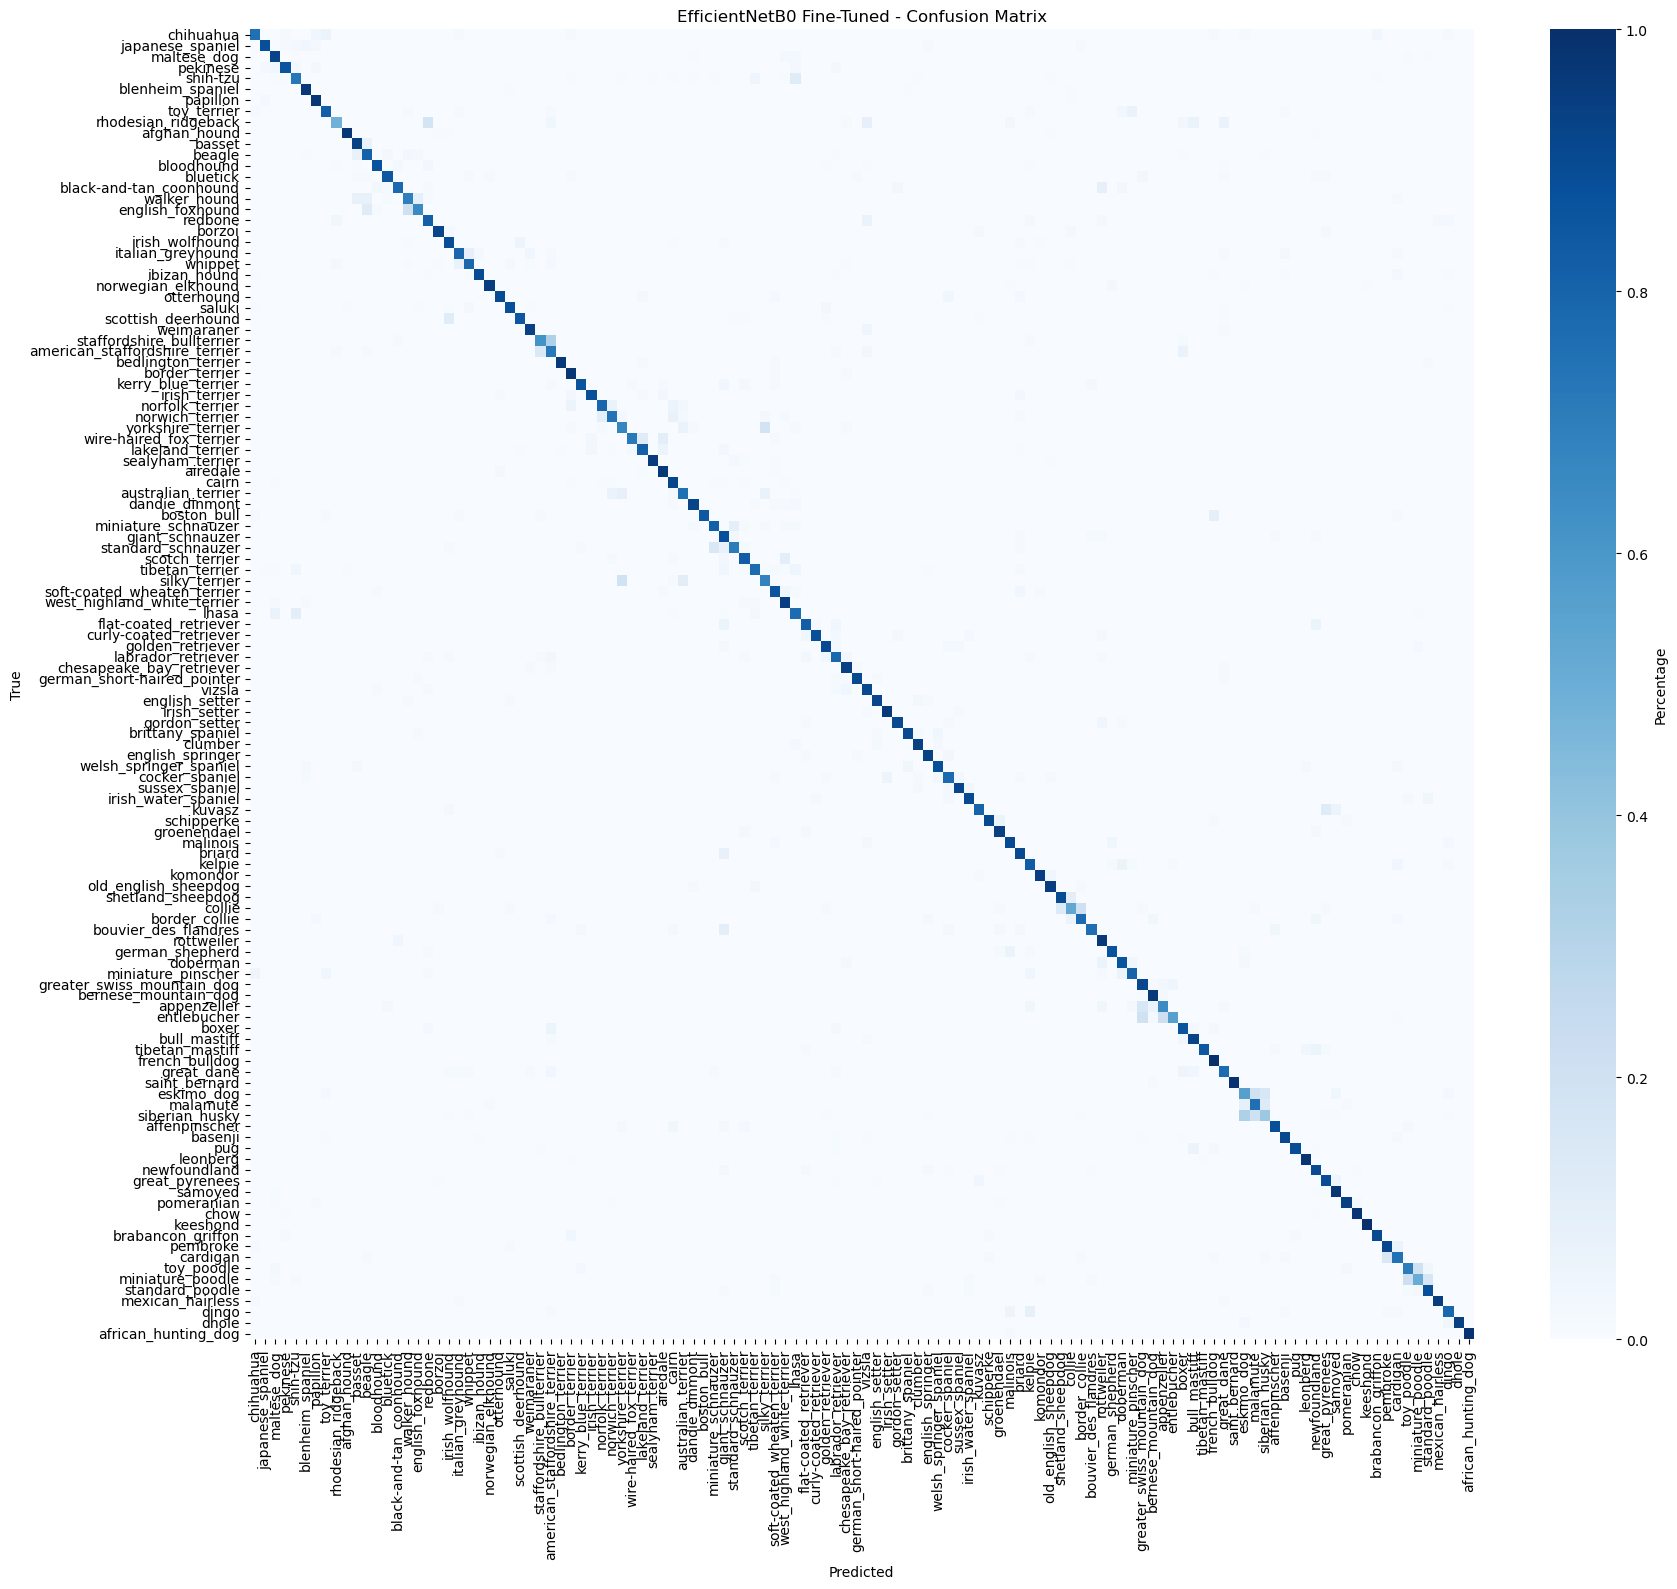

In [10]:
# confusion matrix
from src.evaluation.metrics import get_predictions, compute_confusion_matrix
from src.evaluation.viz import plot_confusion_matrix

y_pred, y_true = get_predictions(best_model, val_prep)
cm = compute_confusion_matrix(y_true, y_pred, num_classes)

plot_confusion_matrix(
    cm,
    class_names,
    normalize=True,
    title=f"{best_model_name} - Confusion Matrix",
    figsize=(18, 16),
    save_path=os.path.join(cfg["paths"]["evaluations"], "best_model_confusion_matrix.png"),
)

Top 20 Most Confused Pairs:
 1.                 siberian_husky -> eskimo_dog                     :  30 errors
 2.                    entlebucher -> appenzeller                    :  22 errors
 3.                    entlebucher -> greater_swiss_mountain_dog     :  20 errors
 4.                 siberian_husky -> malamute                       :  19 errors
 5.      staffordshire_bullterrier -> american_staffordshire_terrier :  18 errors
 6.                  silky_terrier -> yorkshire_terrier              :  16 errors
 7.             scottish_deerhound -> irish_wolfhound                :  15 errors
 8.                       shih-tzu -> lhasa                          :  14 errors
 9.            rhodesian_ridgeback -> redbone                        :  13 errors
10.               english_foxhound -> walker_hound                   :  12 errors
11.              yorkshire_terrier -> silky_terrier                  :  12 errors
12.               miniature_poodle -> toy_poodle                     :

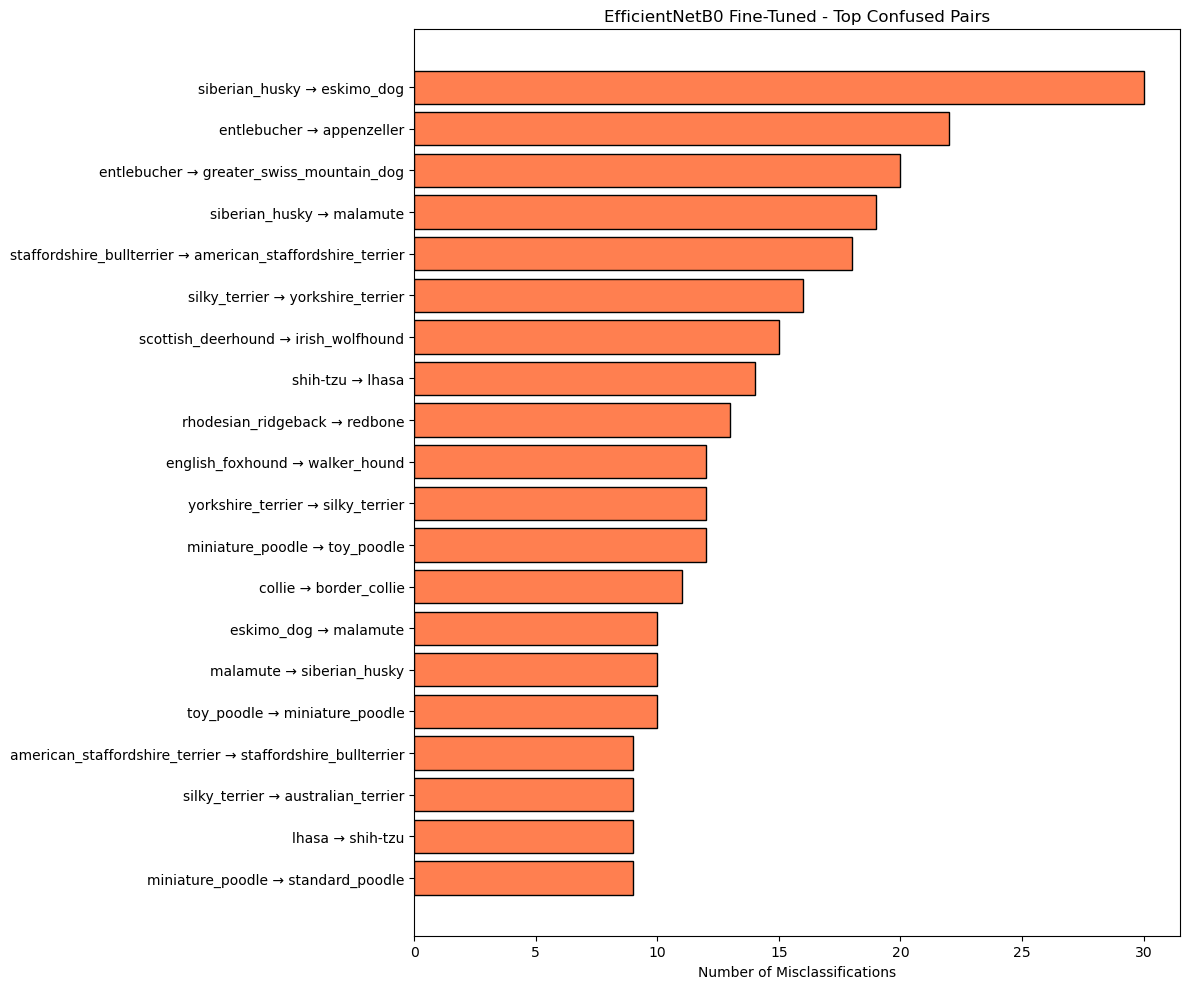

In [11]:
from src.evaluation.metrics import top_confused_pairs
from src.evaluation.viz import plot_top_k_confusion_pairs

confused_pairs = top_confused_pairs(cm, class_names, top_k=20)

print("Top 20 Most Confused Pairs:")
for i, (true_cls, pred_cls, count) in enumerate(confused_pairs, 1):
    print(f"{i:2d}. {true_cls:>30s} -> {pred_cls:<30s} : {count:3d} errors")

plot_top_k_confusion_pairs(
    confused_pairs,
    top_k=20,
    title=f"{best_model_name} - Top Confused Pairs",
    figsize=(12, 10),
    save_path=os.path.join(cfg["paths"]["evaluations"], "best_model_confused_pairs.png"),
)

In [12]:
# per class performance
from src.evaluation.metrics import get_per_class_metrics
from src.evaluation.viz import plot_per_class_f1

per_class_metrics = get_per_class_metrics(y_true, y_pred, class_names)

print("15 Worst Performing Classes:")
print("-" * 72)
worst_15 = list(per_class_metrics.items())[:15]
for name, scores in worst_15:
    print(f"{name:>30s}  F1={scores['f1']:.3f}  Precision={scores['precision']:.3f}  Recall={scores['recall']:.3f}")

print("\n15 Best Performing Classes:")
print("-" * 72)
best_15 = list(per_class_metrics.items())[-15:]
for name, scores in reversed(best_15):
    print(f"{name:>30s}  F1={scores['f1']:.3f}  Precision={scores['precision']:.3f}  Recall={scores['recall']:.3f}")

15 Worst Performing Classes:
------------------------------------------------------------------------
                    eskimo_dog  F1=0.467  Precision=0.400  Recall=0.560
                siberian_husky  F1=0.476  Precision=0.636  Recall=0.380
              miniature_poodle  F1=0.577  Precision=0.667  Recall=0.509
                   appenzeller  F1=0.595  Precision=0.550  Recall=0.647
                        collie  F1=0.596  Precision=0.683  Recall=0.528
           rhodesian_ridgeback  F1=0.619  Precision=0.854  Recall=0.486
american_staffordshire_terrier  F1=0.626  Precision=0.554  Recall=0.719
             yorkshire_terrier  F1=0.637  Precision=0.606  Recall=0.672
     staffordshire_bullterrier  F1=0.673  Precision=0.739  Recall=0.618
                  walker_hound  F1=0.679  Precision=0.661  Recall=0.698
               giant_schnauzer  F1=0.694  Precision=0.575  Recall=0.877
                    toy_poodle  F1=0.699  Precision=0.692  Recall=0.706
                 silky_terrier  F1

Saved plot to ../artefacts/evaluations\best_model_worst_classes.png


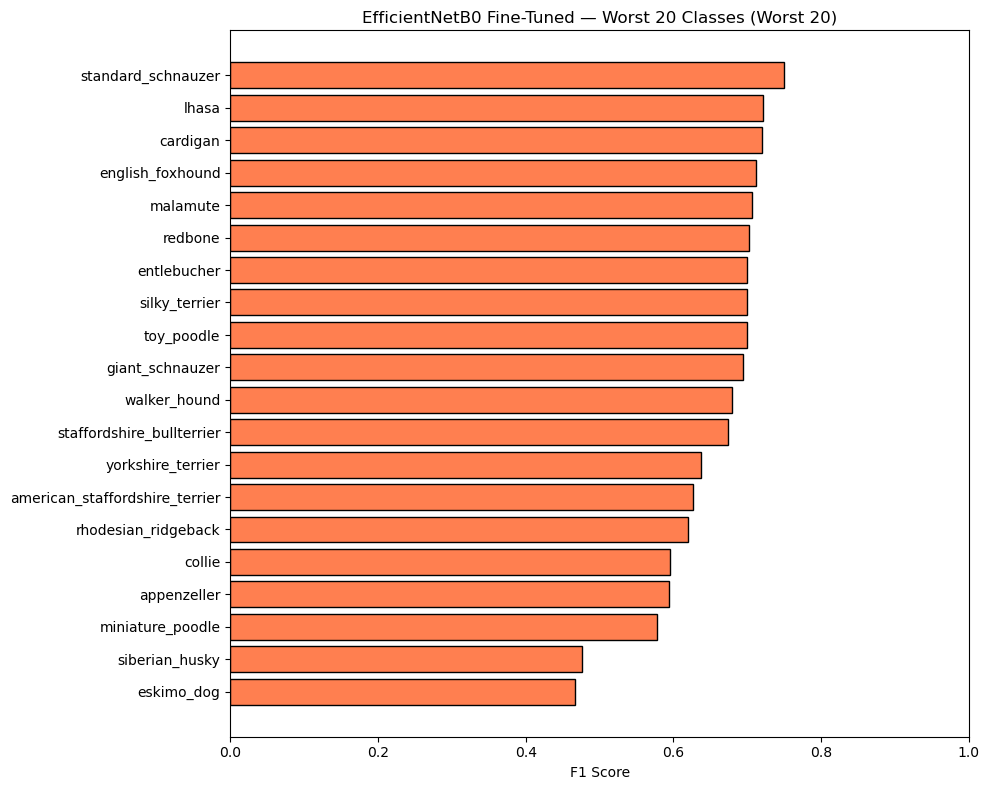

Saved plot to ../artefacts/evaluations\best_model_best_classes.png


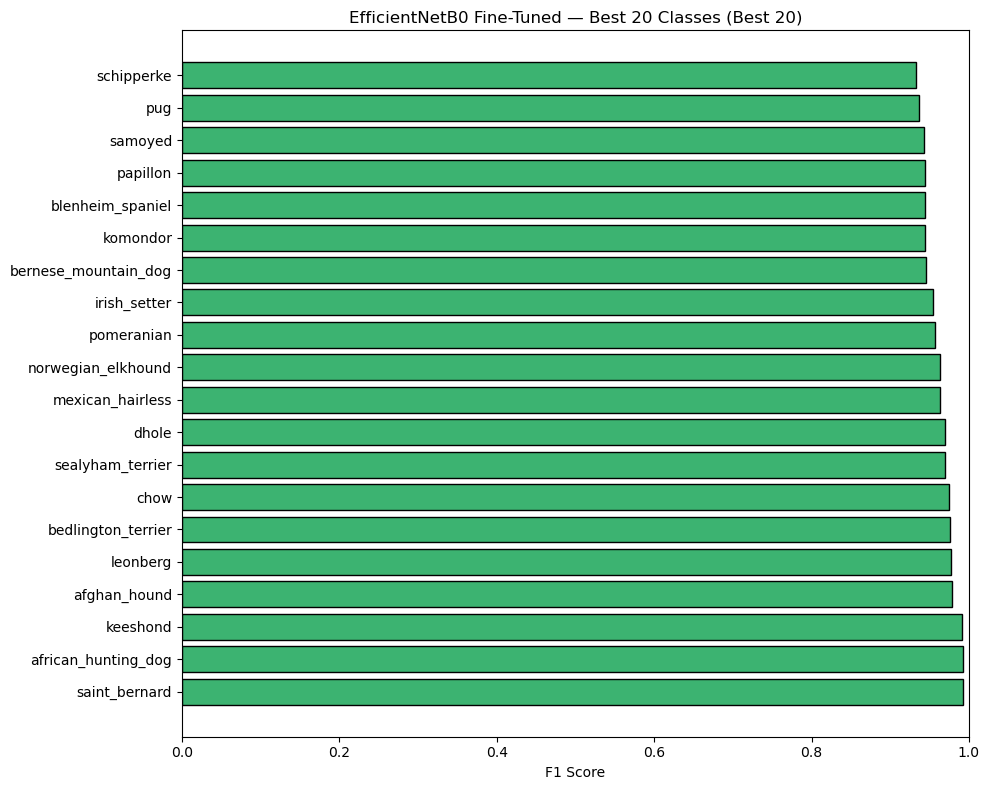

In [13]:
# plot worst 20
plot_per_class_f1(
    per_class_metrics,
    top_n=20,
    worst=True,
    title=f"{best_model_name} — Worst 20 Classes",
    save_path=os.path.join(cfg["paths"]["evaluations"], "best_model_worst_classes.png"),
)

# plot best 20
plot_per_class_f1(
    per_class_metrics,
    top_n=20,
    worst=False,
    title=f"{best_model_name} — Best 20 Classes",
    save_path=os.path.join(cfg["paths"]["evaluations"], "best_model_best_classes.png"),
)

### 7. Save Best Model Info

In [14]:
# Save best model info to text file
best_model_info = {
    "model_name": best_model_name,
    "checkpoint_file": best_checkpoint,
    "val_accuracy": float(results["accuracy"]),
    "val_loss": float(results["loss"]),
    "val_top_5_accuracy": float(results["top_5_accuracy"]),
    "preprocessing_used": model_names_for_prep,
}

info_path = os.path.join(cfg["paths"]["evaluations"], "best_model_info.json")
with open(info_path, "w") as f:
    json.dump(best_model_info, f, indent=2)

print(f"Best model info saved to {info_path}")
print(f"\nBest Model: {best_model_name}")
print(f"Checkpoint: {best_checkpoint}")
print(f"Val Accuracy: {results['accuracy']:.4f}")
print(f"Val Top-5 Accuracy: {results['top_5_accuracy']:.4f}")

Best model info saved to ../artefacts/evaluations\best_model_info.json

Best Model: EfficientNetB0 Fine-Tuned
Checkpoint: efficientnetb0_finetuned.keras
Val Accuracy: 0.8513
Val Top-5 Accuracy: 0.9865


### 8. Summary

**Best Model:**

- Name: EfficientNetB0 Fine-Tuned
- Val Accuracy: 85.13%
- Val Top-5 Accuracy: 98.65%

**Key Findings:**
1. Frozen vs Fine-Tuned: Fine-tuning gave modest results overall, unfreezing last 5 layers of EfficientNetB0 increased accuracy by 0.36% (84.83% -> 85.13%) while unfreezing last 10 layers of ResNet50 increased accuracy by 1.59% (77.56% -> 79.16%)
2. ResNet50 vs EfficientNetB0: EfficientNetB0 outperformed ResNet50 with higher val accuracy and lower loss
3. Fusion Performance: Fusion sits between the two backbones, better than ResNet50 but did not beat EfficientNetB0 in final val accuracy

**Most Difficult Breeds:**
- eskimo_dog -> F1=0.467
- siberian_husky -> F1=0.476
- miniature_poodle -> F1=0.577
- appenzeller -> F1=0.595
- collie -> F1=0.596

**Most Confused Pairs:**
- siberian_husky -> eskimo_dog : 30 errors 
(visual/coat and head-shape similarity among Arctic breeds)
- entlebucher -> appenzeller : 22 errors 
(both Swiss mountain-type dogs with similar build)
- entlebucher -> greater_swiss_mountain_dog : 20 errors
(similar mountain-dog appearance and coat patterns)
